## Download dataset


In [1]:
import kaggle

import os
import random
import json
from tqdm import tqdm

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import IPython.display as ipd
import datasets

import torch
import torch.nn as nn
from transformers import Wav2Vec2Model, Wav2Vec2FeatureExtractor, Wav2Vec2CTCTokenizer, Wav2Vec2Processor
from jiwer import wer
from sklearn.model_selection import train_test_split

from transformers import AutoFeatureExtractor, AutoModelForCTC, AutoTokenizer


from typing import List, Tuple, Set, Dict
%matplotlib inline

SEED = 42
def set_seed(s=SEED):
    random.seed(s); np.random.seed(s); torch.manual_seed(s)
set_seed()

if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")
print('Device:', DEVICE)


Device: mps


In [2]:
#!kaggle datasets download -d /darpa-timit-acousticphonetic-continuous-speech -p timit --unzip

In [3]:
timit = "./timit/"
timit_data = "./timit/data/"

In [4]:
df_train = pd.read_csv(os.path.join(timit, 'train_data.csv'))
df_test = pd.read_csv(os.path.join(timit, 'test_data.csv'))
df = pd.concat([df_train, df_test])
df = df[df['is_converted_audio'] == False]

In [5]:
df_train = df[df['test_or_train'] == "TRAIN"]
df_test  = df[df['test_or_train'] == "TEST"]

In [6]:
df_train.head()


,index,test_or_train,dialect_region,speaker_id,filename,path_from_data_dir,path_from_data_dir_windows,is_converted_audio,is_audio,is_word_file,is_phonetic_file,is_sentence_file
1,2.0,TRAIN,DR4,MMDM0,SI1311.PHN,TRAIN/DR4/MMDM0/SI1311.PHN,TRAIN\\DR4\\MMDM0\\SI1311.PHN,False,False,False,True,False
2,3.0,TRAIN,DR4,MMDM0,SI1311.WRD,TRAIN/DR4/MMDM0/SI1311.WRD,TRAIN\\DR4\\MMDM0\\SI1311.WRD,False,False,True,False,False
3,4.0,TRAIN,DR4,MMDM0,SX321.PHN,TRAIN/DR4/MMDM0/SX321.PHN,TRAIN\\DR4\\MMDM0\\SX321.PHN,False,False,False,True,False
4,5.0,TRAIN,DR4,MMDM0,SX321.WRD,TRAIN/DR4/MMDM0/SX321.WRD,TRAIN\\DR4\\MMDM0\\SX321.WRD,False,False,True,False,False
5,6.0,TRAIN,DR4,MMDM0,SI681.TXT,TRAIN/DR4/MMDM0/SI681.TXT,TRAIN\\DR4\\MMDM0\\SI681.TXT,False,False,False,False,True


In [7]:
df_test.head()

,index,test_or_train,dialect_region,speaker_id,filename,path_from_data_dir,path_from_data_dir_windows,is_converted_audio,is_audio,is_word_file,is_phonetic_file,is_sentence_file
0,1.0,TEST,DR4,MGMM0,SX139.WAV,TEST/DR4/MGMM0/SX139.WAV,TEST\\DR4\\MGMM0\\SX139.WAV,False,True,False,False,False
2,3.0,TEST,DR4,MGMM0,SX139.TXT,TEST/DR4/MGMM0/SX139.TXT,TEST\\DR4\\MGMM0\\SX139.TXT,False,False,False,False,True
3,4.0,TEST,DR4,MGMM0,SI499.WRD,TEST/DR4/MGMM0/SI499.WRD,TEST\\DR4\\MGMM0\\SI499.WRD,False,False,True,False,False
4,5.0,TEST,DR4,MGMM0,SX319.WRD,TEST/DR4/MGMM0/SX319.WRD,TEST\\DR4\\MGMM0\\SX319.WRD,False,False,True,False,False
5,6.0,TEST,DR4,MGMM0,SX319.PHN,TEST/DR4/MGMM0/SX319.PHN,TEST\\DR4\\MGMM0\\SX319.PHN,False,False,False,True,False


In [8]:
PHONETIC = 'phonetic'
AUDIO = 'audio'
WORD = 'word'

phon61_map39 = {
        'iy':'iy',  'ih':'ih',  'eh':'eh',  'ae':'ae',   'ix':'ih',  'ax':'ah',  'ah':'ah',   'uw':'uw',
        'ux':'uw',  'uh':'uh',  'ao':'aa',  'aa':'aa',   'ey':'ey',  'ay':'ay',  'oy':'oy',   'aw':'aw',
        'ow':'ow',  'l':'l',    'el':'l',   'r':'r',     'y':'y',    'w':'w',    'er':'er',   'axr':'er',
        'm':'m',    'em':'m',   'n':'n',    'nx':'n',    'en':'n',   'ng':'ng',  'eng':'ng',  'ch':'ch',
        'jh':'jh',  'dh':'dh',  'b':'b',    'd':'d',     'dx':'dx',  'g':'g',    'p':'p',     't':'t',
        'k':'k',    'z':'z',    'zh':'sh',  'v':'v',     'f':'f',    'th':'th',  's':'s',     'sh':'sh',
        'hh':'hh',  'hv':'hh',  'pcl':'h#', 'tcl':'h#',  'kcl':'h#', 'qcl':'h#', 'bcl':'h#',  'dcl':'h#',
        'gcl':'h#', 'h#':'h#',  '#h':'h#',  'pau':'h#',  'epi':'h#', 'nx':'n',   'ax-h':'ah', 'q':'h#'
    }

def convert_phonetic_to_39(phonetic_map: Dict[str,str], sequence: str) -> str:
    return " ".join(phonetic_map.get(x, x) for x in sequence.split())

def read_text(text_file_path: str) -> str:
    with open(text_file_path, 'r') as file:
        char = [line.split()[-1] for line in file]
        return " ".join(char)
    
def transform_dataset(df: pd.DataFrame) -> Dict[str, List[str]]:
    temp_data = {}
    
    keys_set = {AUDIO, WORD, PHONETIC}

    for _, row in tqdm(df.iterrows(), total=len(df), desc="Processing items"):
        path = row['path_from_data_dir']
        entry_id = "-".join(path.split('.')[0].split('/')[-2:])
        if entry_id not in temp_data:
            temp_data[entry_id] = {}

        full_path = os.path.join(timit_data, path)
        extension = os.path.splitext(path)[1].upper()

        if extension == '.WAV':
            temp_data[entry_id][AUDIO] = full_path
        elif extension == '.WRD':
            temp_data[entry_id][WORD] = read_text(full_path)
        elif extension == '.PHN':
            phoneme_sentence = read_text(full_path)
            temp_data[entry_id][PHONETIC] = convert_phonetic_to_39(phon61_map39, phoneme_sentence)

    results = {AUDIO: [], WORD: [], PHONETIC: []}
    
    for entry in temp_data.values():
        if set(entry.keys()) == keys_set:
            results[AUDIO].append(entry[AUDIO])
            results[WORD].append(entry[WORD])
            results[PHONETIC].append(entry[PHONETIC])

    return results


In [9]:
train_val = transform_dataset(df_train)
test = transform_dataset(df_test)

n = len(train_val[AUDIO])
train_n = int(n * 0.9)
val_n = n - train_n

val_ind = np.array(sorted(random.sample(range(n), val_n)))
train_ind = np.array(sorted(list(set(range(n)) - set(val_ind))))

train = {}
val = {}

for key in [AUDIO, WORD, PHONETIC]:
    train[key] = np.array(train_val[key])[train_ind].tolist()
    val[key]   = np.array(train_val[key])[val_ind].tolist()

print(f"Train set length: {len(train[AUDIO])}")
print(f"Validation set length: {len(val[AUDIO])}")
print(f"Test set length: {len(test[AUDIO])}")

Processing items: 100%|██████████| 6720/6720 [00:00<00:00, 13098.80it/s]


Train set length: 4158
Validation set length: 462
Test set length: 1680


In [10]:
splits = {
    "train": datasets.Dataset.from_dict(train),
    "val":   datasets.Dataset.from_dict(val),
    "test":  datasets.Dataset.from_dict(test)
}

for name in splits:
    splits[name] = splits[name].cast_column(
        AUDIO, 
        datasets.Audio(sampling_rate=16_000)
    )

train_dataset = splits["train"]
val_dataset   = splits["val"]
test_dataset  = splits["test"]

ind = 10
sample = train_dataset[ind]

print(f"Text:           {sample[WORD]}")
print(f"Phonetics:      {sample[PHONETIC]}")
print(f"Array Shape:    {sample[AUDIO]['array'].shape}")
print(f"Sampling Rate:  {sample[AUDIO]['sampling_rate']}")

ipd.Audio(data=sample[AUDIO]["array"], autoplay=False, rate=16_000)

Text:           the coyote bobcat and hyena are wild animals
Phonetics:      h# dh ih h# k ay ow dx iy h# b aa h# b h# k ae h# n hh ay iy n ah h# aa r w aa l dx ae n ih m l z h#
Array Shape:    (58164,)
Sampling Rate:  16000


In [11]:
unique_phonemes = set([' '])

for dataset in [train_dataset, val_dataset, test_dataset]:
    for row in dataset:
        unique_phonemes.update(row[PHONETIC].split())

vocab_list = list(unique_phonemes)

vocab_dict = {v: k for k, v in enumerate(sorted(vocab_list))}
print(vocab_dict)

vocab_dict["|"] = vocab_dict[" "]
del vocab_dict[" "]

vocab_dict["[UNK]"] = len(vocab_dict)
vocab_dict["[PAD]"] = len(vocab_dict)
print(len(vocab_dict))

with open('./vocab.json', 'w') as vocab_file:
    json.dump(vocab_dict, vocab_file)

del df
del df_test
del df_train

{' ': 0, 'aa': 1, 'ae': 2, 'ah': 3, 'aw': 4, 'ay': 5, 'b': 6, 'ch': 7, 'd': 8, 'dh': 9, 'dx': 10, 'eh': 11, 'er': 12, 'ey': 13, 'f': 14, 'g': 15, 'h#': 16, 'hh': 17, 'ih': 18, 'iy': 19, 'jh': 20, 'k': 21, 'l': 22, 'm': 23, 'n': 24, 'ng': 25, 'ow': 26, 'oy': 27, 'p': 28, 'r': 29, 's': 30, 'sh': 31, 't': 32, 'th': 33, 'uh': 34, 'uw': 35, 'v': 36, 'w': 37, 'y': 38, 'z': 39}
42


## Wav2Vec

In [12]:
model = AutoModelForCTC.from_pretrained("facebook/wav2vec2-base-960h", output_hidden_states=True).to(DEVICE)
feature_extractor = AutoFeatureExtractor.from_pretrained("facebook/wav2vec2-base-960h")

Some weights of Wav2Vec2ForCTC were not initialized from the model checkpoint at facebook/wav2vec2-base-960h and are newly initialized: ['wav2vec2.masked_spec_embed']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [13]:
def parameter_counter(input_model, model_name):
    counter = 0
    for param in input_model.parameters():
        counter += param.shape.numel()
    print(f"{model_name} Parameters Count: {f'{counter/1_000_000:.1f}M'}")

parameter_counter(model, "Wav2Vec2")

Wav2Vec2 Parameters Count: 94.4M


In [14]:
ind = 0
audio_array = train_dataset[ind]['audio']['array']
sampling_rate = train_dataset[ind]['audio']['sampling_rate']

inputs = feature_extractor(
    audio_array, 
    sampling_rate=sampling_rate, 
    return_tensors="pt", 
    padding=True
).to(DEVICE)

model.eval()
with torch.no_grad():
    outputs = model(**inputs) 

hidden_states = outputs.hidden_states

for i, hs in enumerate(hidden_states):
    print(f"Layer {i}: {hs.shape}")

Layer 0: torch.Size([1, 270, 768])
Layer 1: torch.Size([1, 270, 768])
Layer 2: torch.Size([1, 270, 768])
Layer 3: torch.Size([1, 270, 768])
Layer 4: torch.Size([1, 270, 768])
Layer 5: torch.Size([1, 270, 768])
Layer 6: torch.Size([1, 270, 768])
Layer 7: torch.Size([1, 270, 768])
Layer 8: torch.Size([1, 270, 768])
Layer 9: torch.Size([1, 270, 768])
Layer 10: torch.Size([1, 270, 768])
Layer 11: torch.Size([1, 270, 768])
Layer 12: torch.Size([1, 270, 768])


In [15]:
from torch.utils.data import Dataset
import torch
from tqdm import tqdm

class PhonemeDataset(Dataset):
    def __init__(self, data, layer_index: int, split_name: str, cache_dir: str = "./cache/phoneme_features"):
        self.items = []
        self.extra = []
        self.layer_index = layer_index
        self.split_name = split_name

        os.makedirs(cache_dir, exist_ok=True)
        cache_path = os.path.join(cache_dir, f"{split_name}_layer_{layer_index}.pt")

        if os.path.exists(cache_path):
            payload = torch.load(cache_path, map_location="cpu", weights_only=False)
            self.items = payload["items"]
            self.extra = payload["extra"]
            print(f"Loaded cached features for {split_name}, layer {layer_index}")
            return

        print(f"Extracting features for {split_name}, layer {layer_index}...")

        for row in tqdm(data, desc=f"Processing {split_name} rows"):
            inputs = feature_extractor(
                row[AUDIO]["array"],
                sampling_rate=row[AUDIO]["sampling_rate"],
                return_tensors="pt",
                padding=True
            ).input_values.to(DEVICE)

            with torch.no_grad():
                hidden_states = model(input_values=inputs, output_hidden_states=True).hidden_states
                features = hidden_states[layer_index].squeeze(0).cpu()

            phoneme_ids = [vocab_dict.get(token, vocab_dict["[UNK]"]) for token in row[PHONETIC].split()]
            labels = torch.tensor(phoneme_ids, dtype=torch.long)

            self.items.append({"features": features, "labels": labels})
            self.extra.append({
                AUDIO: row[AUDIO],
                WORD: row[WORD],
                PHONETIC: row[PHONETIC]
            })

        torch.save({"items": self.items, "extra": self.extra}, cache_path)
        print(f"Saved cached features to {cache_path}")

    def __len__(self) -> int:
        return len(self.items)

    def __getitem__(self, idx: int) -> dict:
        return self.items[idx]

    def get_extra_data(self, idx: int) -> dict:
        return self.extra[idx]

In [16]:
def layer_position_to_name(layer_index: int) -> str:
    return "feature_projection" if layer_index == 0 else f"encoder_{layer_index}"


def build_layer_datasets(layer_index: int) -> tuple:
    train_ds = PhonemeDataset(train_dataset, layer_index=layer_index, split_name="train")
    val_ds = PhonemeDataset(val_dataset, layer_index=layer_index, split_name="val")
    test_ds = PhonemeDataset(test_dataset, layer_index=layer_index, split_name="test")
    return train_ds, val_ds, test_ds


available_layer_indices = list(range(model.config.num_hidden_layers + 1))
default_layer_index = available_layer_indices[-1]

train_dataset_torch, val_dataset_torch, test_dataset_torch = build_layer_datasets(default_layer_index)
print(f"Prepared default datasets for {layer_position_to_name(default_layer_index)}")

Loaded cached features for train, layer 12
Loaded cached features for val, layer 12
Loaded cached features for test, layer 12
Prepared default datasets for encoder_12


In [17]:
import torch.nn as nn

class LinearHead(nn.Module):
    def __init__(self, input_dim: int, output_dim: int):
        super().__init__()
        self.fc = nn.Linear(input_dim, output_dim)

    def forward(self, x):
        return self.fc(x)
    
class MLPHead(nn.Module):
    def __init__(self, input_dim: int, hidden_dim: int, output_dim: int, dropout: float = 0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, x):
        return self.net(x)
    
class RecurrentHead(nn.Module):
    def __init__(self, input_dim: int, hidden_dim: int, output_dim: int, num_layers: int = 1):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            bidirectional=True,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_dim * 2, output_dim)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        return self.fc(lstm_out)
    
class Conv1DHead(nn.Module):
    def __init__(self, input_dim: int, hidden_dim: int, output_dim: int, kernel_size: int = 5):
        super().__init__()
        padding = kernel_size // 2 
        
        self.conv = nn.Conv1d(
            in_channels=input_dim,
            out_channels=hidden_dim,
            kernel_size=kernel_size,
            padding=padding
        )
        self.activation = nn.ReLU()
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        x = x.transpose(1, 2)
        
        x = self.conv(x)
        x = self.activation(x)

        x = x.transpose(1, 2)
        return self.fc(x)
    
class LiteConformerHead(nn.Module):
    def __init__(self, input_dim: int, output_dim: int, num_heads: int = 4, kernel_size: int = 5):
        super().__init__()
        self.attention = nn.MultiheadAttention(embed_dim=input_dim, num_heads=num_heads, batch_first=True)
        
        padding = kernel_size // 2
        self.conv = nn.Conv1d(
            in_channels=input_dim, 
            out_channels=input_dim, 
            kernel_size=kernel_size, 
            padding=padding, 
            groups=input_dim 
        )
        
        self.fc = nn.Linear(input_dim, output_dim)

    def forward(self, x):
        attn_out, _ = self.attention(x, x, x)
        x = x + attn_out 
        x_conv = x.transpose(1, 2)
        x_conv = self.conv(x_conv)
        x = x + x_conv.transpose(1, 2) 

        return self.fc(x)

In [18]:
def custom_collate_fn(batch_items: list) -> tuple:
    
    seqs = [item['features'] for item in batch_items]
    targets = [item['labels'] for item in batch_items]

    input_lengths = torch.tensor([seq.shape[0] for seq in seqs], dtype=torch.long)
    x_padded = torch.nn.utils.rnn.pad_sequence(seqs, batch_first=True)

    y_flat = torch.cat(targets).long()
    target_lengths = torch.tensor([len(y) for y in targets], dtype=torch.long)

    return x_padded, input_lengths, y_flat, target_lengths


def decode_ctc_predictions(model_head: nn.Module, x_features: torch.Tensor, id2char: dict, blank_id: int) -> str:
    
    model_head.eval()
    
    with torch.no_grad():
        logits = model_head(x_features.to(DEVICE)).cpu()
    
    predicted_ids = logits.argmax(dim=-1).squeeze(0).tolist()
    collapsed_phonemes = []
    previous_id = None
    ignored_tokens = {"|", "[PAD]", "[UNK]"}
    
    for current_id in predicted_ids:
        if current_id != previous_id and current_id != blank_id:
            token = id2char.get(current_id, "")
            if token and token not in ignored_tokens:
                collapsed_phonemes.append(token)
        
        previous_id = current_id
        
    return " ".join(collapsed_phonemes).strip()


def evaluate_and_display_sample(model: nn.Module, dataset, index: int, id2char: dict, blank_id: int):
    
    metadata = dataset.get_extra_data(index)
    actual_text = metadata[WORD]
    actual_phonemes = metadata[PHONETIC]
    raw_audio = metadata[AUDIO]["array"]
    sample_features = dataset[index]['features'].unsqueeze(0)
    hypothesis = decode_ctc_predictions(model, sample_features, id2char, blank_id)
    
    print(f"Original Text: {actual_text}")
    print(f"Phone Error Rate (PER): {wer(reference=actual_phonemes, hypothesis=hypothesis):.3f}")
    print(f"Ground Truth: {actual_phonemes}")
    print(f"Model Output: {hypothesis}")
    
    return raw_audio

In [19]:
import torch
import torch.nn as nn
from typing import Dict, Tuple
from torch.utils.data import DataLoader
from tqdm import tqdm

def decode_batch_predictions(logits: torch.Tensor, input_lengths: torch.Tensor, id2char: Dict[int, str], blank_idx: int) -> list[str]:
    predicted_ids = logits.argmax(dim=-1)
    ignored_tokens = {"|", "[PAD]", "[UNK]"}
    decoded_sequences = []

    for batch_idx, seq_len in enumerate(input_lengths.tolist()):
        pred_tokens = []
        previous_token = None
        for current_token in predicted_ids[batch_idx, :seq_len].tolist():
            if current_token != previous_token and current_token != blank_idx:
                token = id2char.get(current_token, "")
                if token and token not in ignored_tokens:
                    pred_tokens.append(token)
            previous_token = current_token
        decoded_sequences.append(" ".join(pred_tokens))

    return decoded_sequences


def run_train_step(network: nn.Module, dataloader: DataLoader, loss_fn: nn.Module, optim: torch.optim.Optimizer, hide_progress: bool = False) -> float:
    network.train()
    cumulative_loss = 0.0
    valid_steps = 0

    for x_batch, x_lengths, y_flat, y_lengths in tqdm(dataloader, disable=hide_progress, desc="Training"):
        x_batch = x_batch.to(DEVICE)
        x_lengths = x_lengths.to(DEVICE)
        y_flat = y_flat.to(DEVICE)
        y_lengths = y_lengths.to(DEVICE)

        optim.zero_grad()
        predictions = network(x_batch)
        log_probs = predictions.log_softmax(dim=-1).transpose(0, 1)

        if DEVICE.type == "mps":
            cost = loss_fn(log_probs.cpu(), y_flat.cpu(), x_lengths.cpu(), y_lengths.cpu())
        else:
            cost = loss_fn(log_probs, y_flat, x_lengths, y_lengths)

        if not torch.isfinite(cost):
            continue

        cost.backward()
        optim.step()

        cumulative_loss += cost.item()
        valid_steps += 1

    return cumulative_loss / max(valid_steps, 1)


def compute_validation_metric(network: nn.Module, dataloader: DataLoader, id2char: Dict[int, str], blank_idx: int, hide_progress: bool = False) -> float:
    network.eval()
    total_error_rate = 0.0
    sample_count = 0
    ignored_tokens = {"|", "[PAD]", "[UNK]"}

    with torch.no_grad():
        for x_batch, x_lengths, y_flat, y_lengths in tqdm(dataloader, disable=hide_progress, desc="Evaluating"):
            logits = network(x_batch.to(DEVICE)).cpu()
            decoded_predictions = decode_batch_predictions(logits, x_lengths, id2char, blank_idx)

            offset = 0
            for sample_idx, target_len in enumerate(y_lengths.tolist()):
                target_ids = y_flat[offset:offset + target_len].tolist()
                truth_tokens = [id2char[val] for val in target_ids if val in id2char and id2char[val] not in ignored_tokens]
                truth_string = " ".join(truth_tokens)
                pred_string = decoded_predictions[sample_idx]

                total_error_rate += wer(reference=truth_string, hypothesis=pred_string)
                sample_count += 1
                offset += target_len

    return total_error_rate / max(sample_count, 1)


def execute_training_loop(network: nn.Module, 
                          train_dl: DataLoader, 
                          val_dl: DataLoader, 
                          loss_fn: nn.Module, 
                          optim: torch.optim.Optimizer, 
                          id2char: Dict[int, str], 
                          blank_idx: int,
                          save_path: str,
                          test_dl: DataLoader | None = None,
                          max_epochs: int = 100,
                          top_per: float = float("inf"),
                          hide_progress: bool = False) -> Tuple[list[dict], float, float, float, int]:
    history = []
    best_test_per = float("nan")
    best_epoch = -1
    avg_loss = float("nan")
    os.makedirs(os.path.dirname(save_path), exist_ok=True)

    for epoch in range(max_epochs):
        avg_loss = run_train_step(network, train_dl, loss_fn, optim, hide_progress)
        current_per = compute_validation_metric(network, val_dl, id2char, blank_idx, hide_progress)
        current_test_per = None
        if test_dl is not None:
            current_test_per = compute_validation_metric(network, test_dl, id2char, blank_idx, hide_progress)

        history.append({
            "epoch": epoch + 1,
            "train_loss": avg_loss,
            "val_per": current_per,
            "test_per": current_test_per
        })

        if current_per < top_per:
            torch.save(network.state_dict(), save_path)
            top_per = current_per
            best_test_per = current_test_per if current_test_per is not None else float("nan")
            best_epoch = epoch + 1

        if not hide_progress:
            test_msg = f" | Test PER: {current_test_per:.4f}" if current_test_per is not None else ""
            print(f"Epoch [{epoch + 1:03d}/{max_epochs:03d}] | "
                  f"Loss: {avg_loss:.4f} | "
                  f"Val PER: {current_per:.4f}{test_msg} | "
                  f"Best Val PER: {top_per:.4f}")

    return history, avg_loss, top_per, best_test_per, best_epoch

In [20]:
id_to_token = {val: key for key, val in vocab_dict.items()}

In [ ]:
import os
import gc
import json
import torch
import torch.nn as nn
import pandas as pd
from torch.utils.data import DataLoader

audio_feature_dim = 768
train_batch_size = 16
blank_token_id = len(vocab_dict)
num_classes = blank_token_id + 1
learning_rate = 1e-4
total_epochs = 10
results_dir = "./results/wav2vec2"
checkpoints_dir = "./weights/wav2vec2"
os.makedirs(results_dir, exist_ok=True)
os.makedirs(checkpoints_dir, exist_ok=True)


def release_memory() -> None:
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    if hasattr(torch, "mps") and torch.backends.mps.is_available():
        torch.mps.empty_cache()


def build_model_zoo(input_dim: int, output_dim: int) -> dict:
    return {
        "Linear": LinearHead(input_dim=input_dim, output_dim=output_dim),
        "MLP": MLPHead(input_dim=input_dim, hidden_dim=512, output_dim=output_dim, dropout=0.5),
        "BiLSTM": RecurrentHead(input_dim=input_dim, hidden_dim=256, output_dim=output_dim, num_layers=1),
        "Conv1D": Conv1DHead(input_dim=input_dim, hidden_dim=512, output_dim=output_dim, kernel_size=5),
        "LiteConformer": LiteConformerHead(input_dim=input_dim, output_dim=output_dim, num_heads=4, kernel_size=5)
    }


def persist_benchmark_outputs(summary_rows: list[dict], history_rows: list[dict]) -> None:
    summary_df = pd.DataFrame(summary_rows)
    if not summary_df.empty:
        summary_df = summary_df.sort_values(["best_val_per", "final_test_per"], ascending=[True, True])
        summary_df.to_csv(os.path.join(results_dir, "benchmark_summary.csv"), index=False)
        summary_df.to_json(os.path.join(results_dir, "benchmark_summary.json"), orient="records", indent=2)

    history_df = pd.DataFrame(history_rows)
    history_df.to_csv(os.path.join(results_dir, "benchmark_history.csv"), index=False)
    history_df.to_json(os.path.join(results_dir, "benchmark_history.json"), orient="records", indent=2)


benchmark_summary = []
benchmark_history = []

print("Starting Layer-by-Layer Architecture Benchmarking...")

for layer_index in available_layer_indices:
    layer_name = layer_position_to_name(layer_index)
    print("\n" + "#" * 60)
    print(f"LAYER POSITION: {layer_name} (index={layer_index})")
    print("#" * 60)

    train_dataset_torch, val_dataset_torch, test_dataset_torch = build_layer_datasets(layer_index)

    train_dl = DataLoader(train_dataset_torch, batch_size=train_batch_size, shuffle=True, collate_fn=custom_collate_fn)
    val_dl = DataLoader(val_dataset_torch, batch_size=1, shuffle=False, collate_fn=custom_collate_fn)
    test_dl = DataLoader(test_dataset_torch, batch_size=1, shuffle=False, collate_fn=custom_collate_fn)
    ctc_criterion = nn.CTCLoss(blank=blank_token_id, zero_infinity=True)

    for model_name, current_network in build_model_zoo(audio_feature_dim, num_classes).items():
        print("\n" + "=" * 50)
        print(f" TRAINING HEAD: {model_name} | LAYER: {layer_name}")
        print("=" * 50)

        current_network = current_network.to(DEVICE)
        adam_optimizer = torch.optim.Adam(current_network.parameters(), lr=learning_rate)
        save_file = os.path.join(checkpoints_dir, f"{layer_name}_{model_name.lower()}_head.pt")

        history, final_train_loss, best_val_per, best_test_per, best_epoch = execute_training_loop(
            network=current_network,
            train_dl=train_dl,
            val_dl=val_dl,
            test_dl=test_dl,
            loss_fn=ctc_criterion,
            optim=adam_optimizer,
            id2char=id_to_token,
            blank_idx=blank_token_id,
            save_path=save_file,
            max_epochs=total_epochs
        )

        if os.path.exists(save_file):
            current_network.load_state_dict(torch.load(save_file, map_location="cpu"))
            current_network = current_network.to(DEVICE)

        final_test_per = compute_validation_metric(
            network=current_network,
            dataloader=test_dl,
            id2char=id_to_token,
            blank_idx=blank_token_id
        )

        summary_row = {
            "layer_index": layer_index,
            "layer_name": layer_name,
            "head": model_name,
            "final_train_loss": final_train_loss,
            "best_val_per": best_val_per,
            "test_per_at_best_val": best_test_per,
            "final_test_per": final_test_per,
            "best_epoch": best_epoch,
            "checkpoint_path": save_file
        }
        benchmark_summary.append(summary_row)

        for epoch_row in history:
            benchmark_history.append({
                "layer_index": layer_index,
                "layer_name": layer_name,
                "head": model_name,
                **epoch_row
            })

        persist_benchmark_outputs(benchmark_summary, benchmark_history)

        del current_network
        del adam_optimizer
        del history
        release_memory()

    del train_dl
    del val_dl
    del test_dl
    del train_dataset_torch
    del val_dataset_torch
    del test_dataset_torch
    del ctc_criterion
    release_memory()

leaderboard = pd.DataFrame(benchmark_summary).sort_values(["best_val_per", "final_test_per"], ascending=[True, True])
print("\n" + "BENCHMARKING COMPLETE".center(70))
print("=" * 70)
print(leaderboard[["layer_name", "head", "best_val_per", "test_per_at_best_val", "final_test_per", "best_epoch"]].to_string(index=False))
print("=" * 70)
print(f"Saved summary to {os.path.join(results_dir, 'benchmark_summary.csv')}")
print(f"Saved history to {os.path.join(results_dir, 'benchmark_history.csv')}")
release_memory()

Starting Layer-by-Layer Architecture Benchmarking...

############################################################
LAYER POSITION: feature_projection (index=0)
############################################################
Loaded cached features for train, layer 0
Loaded cached features for val, layer 0
Loaded cached features for test, layer 0

 TRAINING HEAD: Linear | LAYER: feature_projection


Evaluating: 100%|██████████| 1680/1680 [00:01<00:00, 1583.47it/s]


Epoch [001/010] | Loss: 9.5423 | Val PER: 0.6463 | Test PER: 0.6627 | Best Val PER: 0.6463


Evaluating: 100%|██████████| 1680/1680 [00:00<00:00, 1845.44it/s]


Epoch [002/010] | Loss: 5.4842 | Val PER: 0.6680 | Test PER: 0.6786 | Best Val PER: 0.6463


...

Epoch [009/010] | Loss: 0.6510 | Val PER: 0.2227 | Test PER: 0.2184 | Best Val PER: 0.2227


Evaluating: 100%|██████████| 1680/1680 [00:16<00:00, 104.09it/s]


Epoch [010/010] | Loss: 0.6262 | Val PER: 0.2117 | Test PER: 0.2017 | Best Val PER: 0.2117


Evaluating: 100%|██████████| 1680/1680 [00:17<00:00, 95.27it/s] 



                      🏆 BENCHMARKING COMPLETE 🏆                       
        layer_name          head  best_val_per  test_per_at_best_val  final_test_per  best_epoch
         encoder_9        Conv1D      0.107274              0.104156        0.104156           9
         encoder_7        Conv1D      0.107617              0.101625        0.101625          10
         encoder_9        BiLSTM      0.107657              0.103196        0.103196          10
         encoder_8        BiLSTM      0.108531              0.105938        0.105938          10
        encoder_10        BiLSTM      0.108735              0.106393        0.106393          10
         encoder_6        Conv1D      0.109694              0.103850        0.103850          10
         encoder_7        BiLSTM      0.112053              0.108702        0.108702          10
         encoder_8        Conv1D      0.113342              0.108313        0.108313           9
         encoder_5        Conv1D      0.114055         

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def load_and_process_logs(json_file_path: str) -> pd.DataFrame:
    df = pd.read_json(json_file_path)
    best_indices = df.groupby(['layer_index', 'head'])['val_per'].idxmin()
    return df.loc[best_indices].reset_index(drop=True)

def chart_layer_metrics(df_best: pd.DataFrame, base_model_name: str, target_head: str = None):
    fig, ax = plt.subplots(figsize=(9, 5))
    bar_width = 0.35
    
    if target_head:
        plot_data = df_best[df_best['head'] == target_head].sort_values('layer_index')
        chart_title = f"{base_model_name}: Layer Performance using '{target_head}' Head"
    else:
        plot_data = df_best.groupby('layer_index')[['val_per', 'test_per']].mean().reset_index()
        chart_title = f"{base_model_name}: Average Layer Performance (All Heads)"

    x_positions = np.arange(len(plot_data))
    
    ax.bar(x_positions - bar_width/2, plot_data['val_per'], width=bar_width, label="Val PER", color="#4C72B0")
    ax.bar(x_positions + bar_width/2, plot_data['test_per'], width=bar_width, label="Test PER", color="#DD8452")

    ax.set_xticks(x_positions)
    ax.set_xticklabels([f"Layer {int(idx)}" for idx in plot_data['layer_index']])
    ax.set_ylabel("Phone Error Rate")
    ax.set_title(chart_title)
    ax.grid(axis="y", linestyle=":", alpha=0.7)
    ax.legend()
    
    plt.tight_layout()
    plt.show()


def chart_head_metrics(df_best: pd.DataFrame, base_model_name: str, target_layer: int = None):
    fig, ax = plt.subplots(figsize=(9, 5))
    bar_w = 0.35
    
    if target_layer is not None:
        plot_data = df_best[df_best['layer_index'] == target_layer].sort_values('head')
        chart_title = f"Head Architecture Comparison ({base_model_name} Layer {target_layer})"
    else:
        plot_data = df_best.groupby('head')[['val_per', 'test_per']].mean().reset_index()
        chart_title = "Average Head Architecture Comparison"

    x_positions = np.arange(len(plot_data))
    
    ax.bar(x_positions - bar_w/2, plot_data['val_per'], width=bar_w, label="Val PER", color="#55A868")
    ax.bar(x_positions + bar_w/2, plot_data['test_per'], width=bar_w, label="Test PER", color="#C44E52")

    ax.set_xticks(x_positions)
    ax.set_xticklabels(plot_data['head'], rotation=25, ha='right')
    ax.set_ylabel("Phone Error Rate")
    ax.set_title(chart_title)
    ax.grid(axis="y", linestyle=":", alpha=0.7)
    ax.legend()
    
    plt.tight_layout()
    plt.show()


def highlight_top_layer_per_head(df_best: pd.DataFrame, base_model_name: str):
    top_indices = df_best.groupby('head')['val_per'].idxmin()
    top_data = df_best.loc[top_indices].reset_index(drop=True)
    
    fig, ax = plt.subplots(figsize=(9, 5))
    x_pos = np.arange(len(top_data))
    bw = 0.38
    
    ax.bar(x_pos - bw/2, top_data['val_per'], width=bw, label="Val PER", color="#8172B3")
    ax.bar(x_pos + bw/2, top_data['test_per'], width=bw, label="Test PER", color="#937860")
    
    for index, row in top_data.iterrows():
        label_text = f"L{int(row['layer_index'])}"
        ax.text(index - bw/2, row['val_per'] + 0.005, label_text, ha='center', fontweight='bold', color='indigo')

    ax.set_xticks(x_pos)
    ax.set_xticklabels(top_data['head'], rotation=25, ha='right')
    ax.set_ylabel("Phone Error Rate")
    ax.set_title(f"Optimal {base_model_name} Layer for Each Head")
    ax.grid(axis="y", linestyle=":", alpha=0.7)
    ax.legend()
    
    plt.tight_layout()
    plt.show()


def highlight_top_head_per_layer(df_best: pd.DataFrame, base_model_name: str):
    top_indices = df_best.groupby('layer_index')['val_per'].idxmin()
    top_data = df_best.loc[top_indices].sort_values('layer_index').reset_index(drop=True)
    
    fig, ax = plt.subplots(figsize=(10, 5))
    x_pos = np.arange(len(top_data))
    bw = 0.38
    
    ax.bar(x_pos - bw/2, top_data['val_per'], width=bw, label="Val PER", color="#64B5CD")
    ax.bar(x_pos + bw/2, top_data['test_per'], width=bw, label="Test PER", color="#CCB974")
    
    for index, row in top_data.iterrows():
        label_text = str(row['head'])
        ax.text(index - bw/2, row['val_per'] + 0.005, label_text, ha='center', fontsize=9, rotation=15, color='darkcyan')

    ax.set_xticks(x_pos)
    ax.set_xticklabels([f"Layer {int(idx)}" for idx in top_data['layer_index']])
    ax.set_ylabel("Phone Error Rate")
    ax.set_title(f"Optimal Head Architecture for Each {base_model_name} Layer")
    ax.grid(axis="y", linestyle=":", alpha=0.7)
    ax.legend()
    
    plt.tight_layout()
    plt.show()

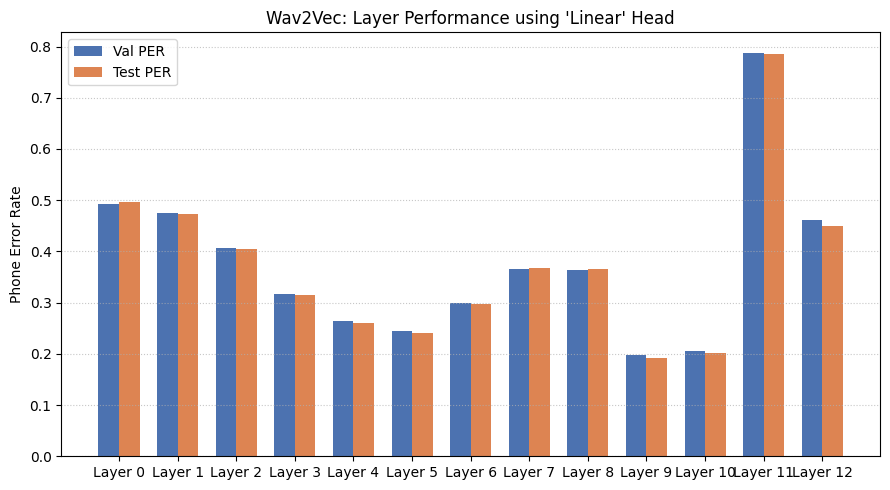

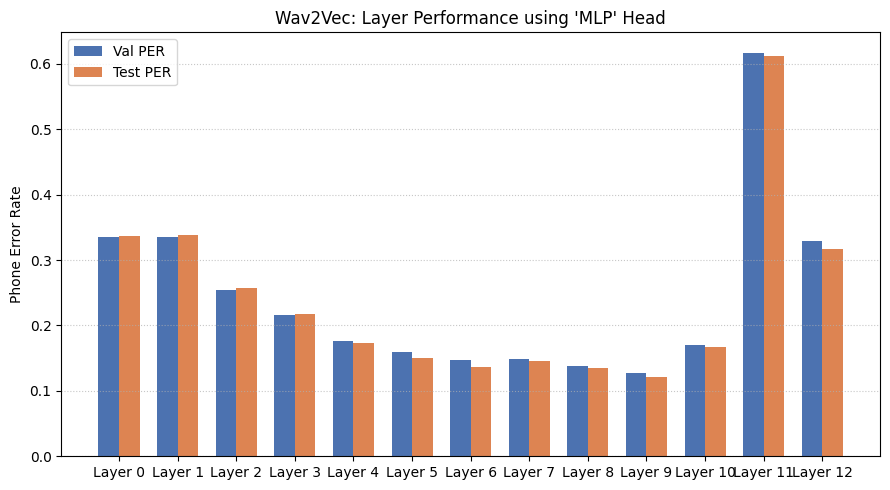

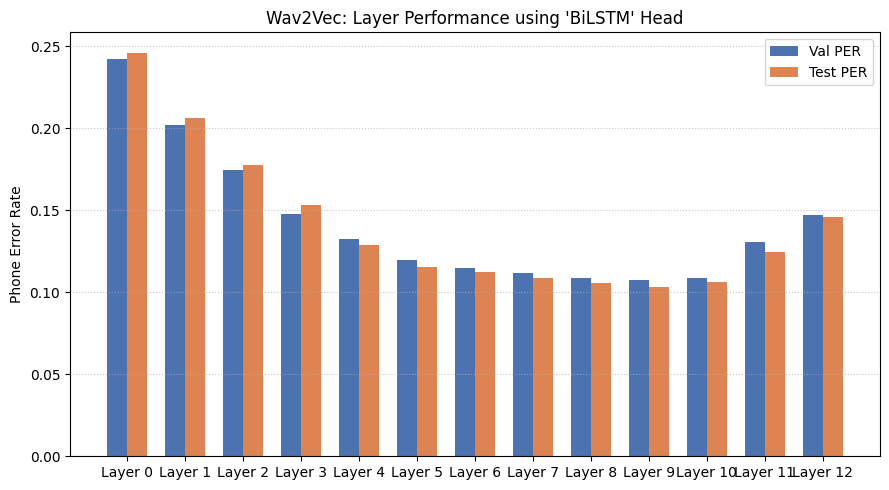

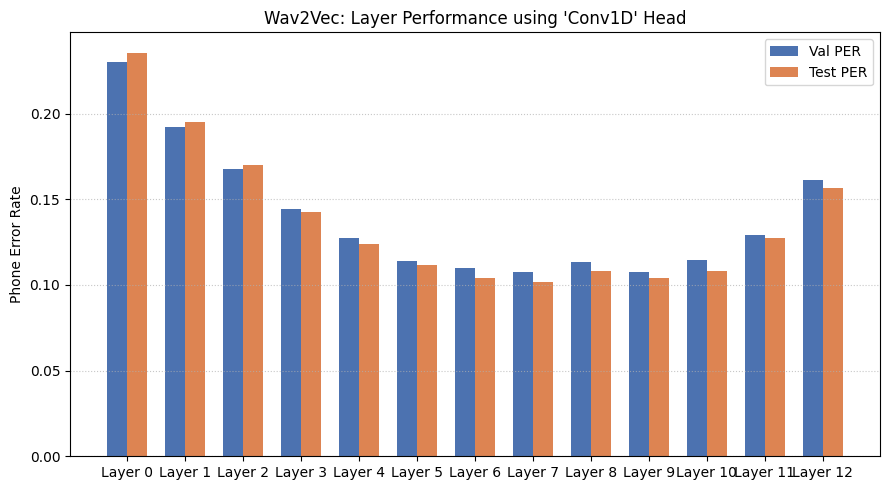

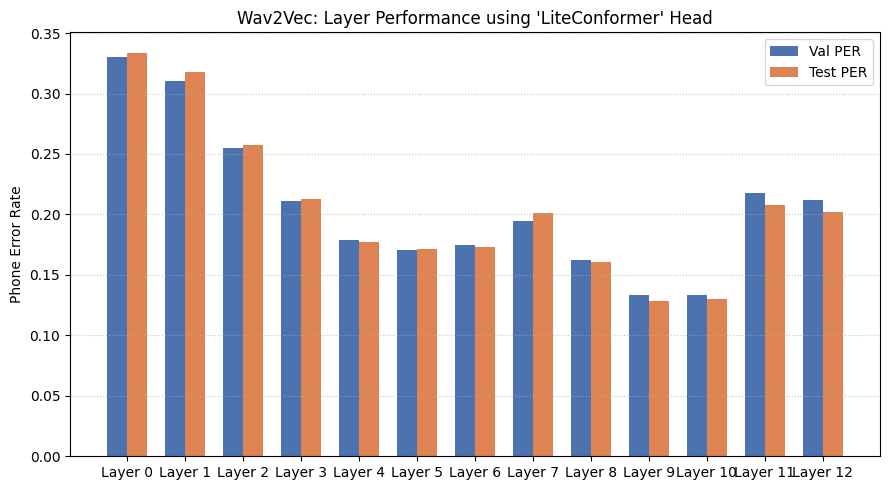

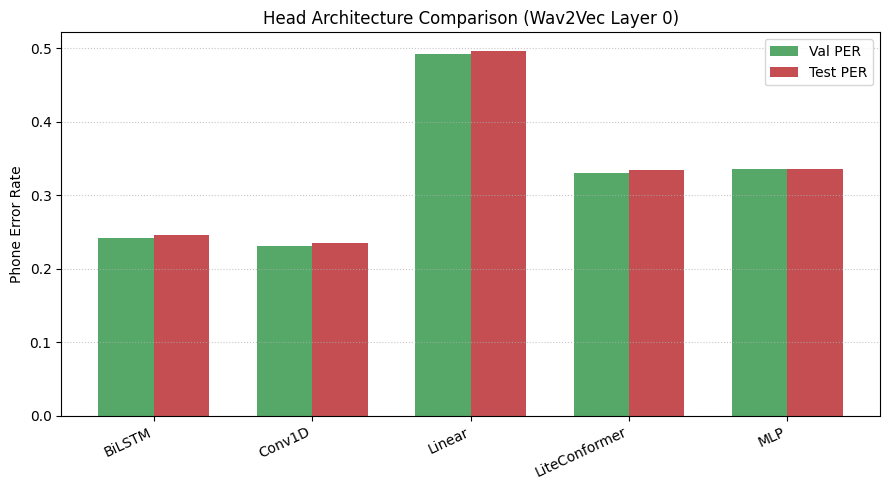

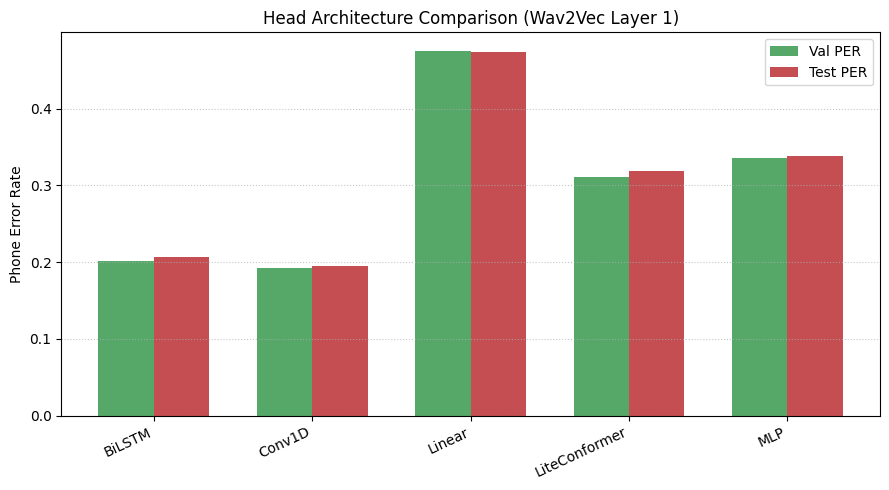

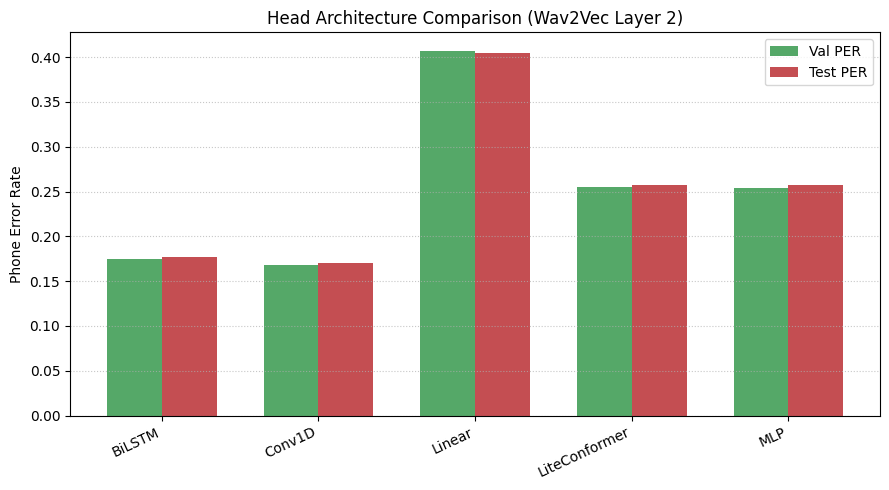

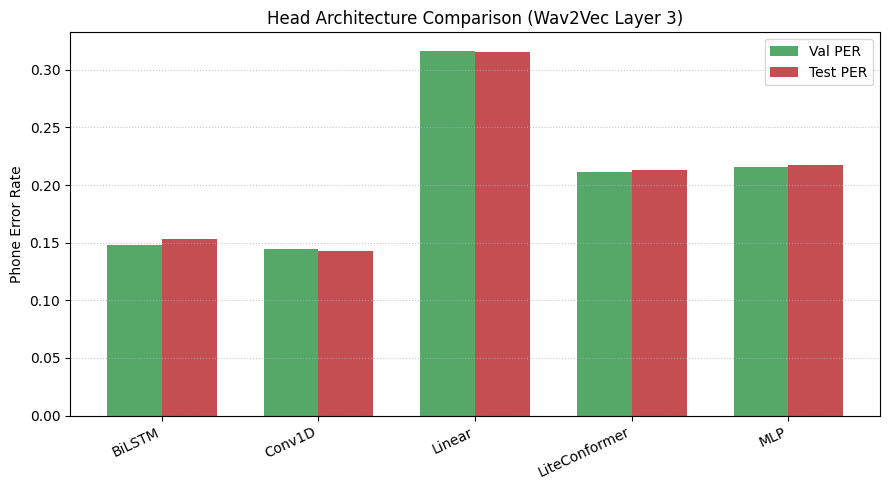

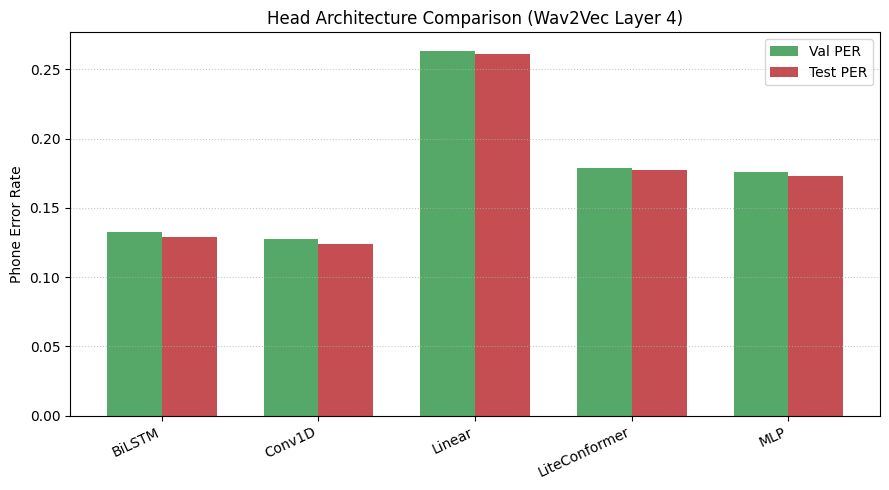

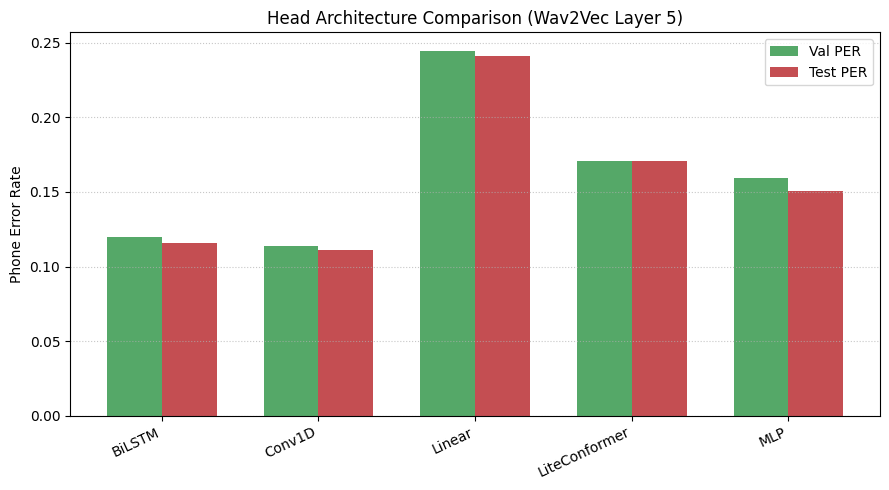

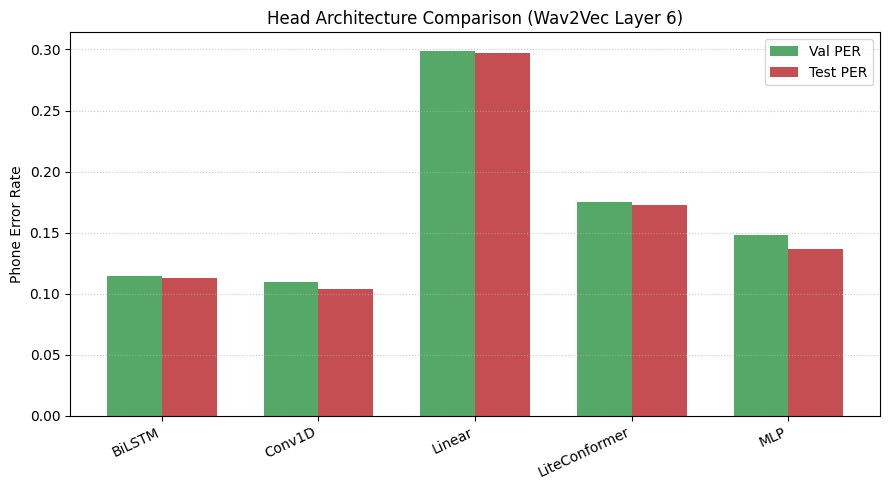

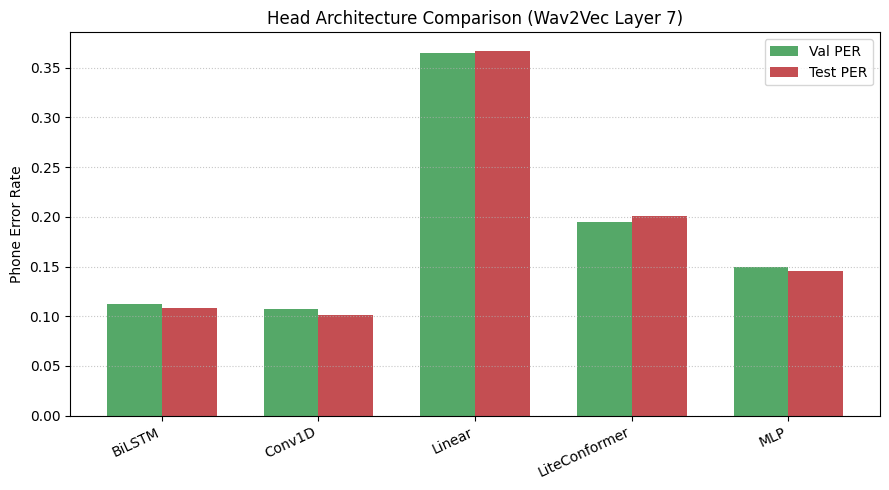

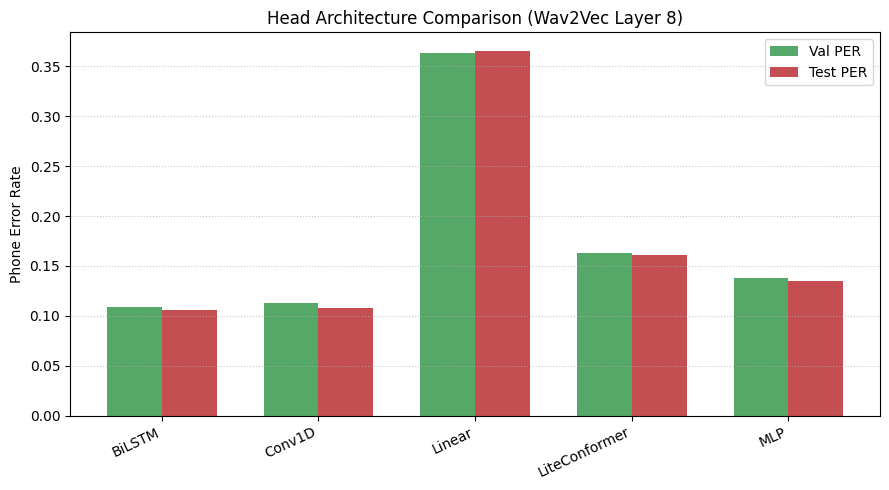

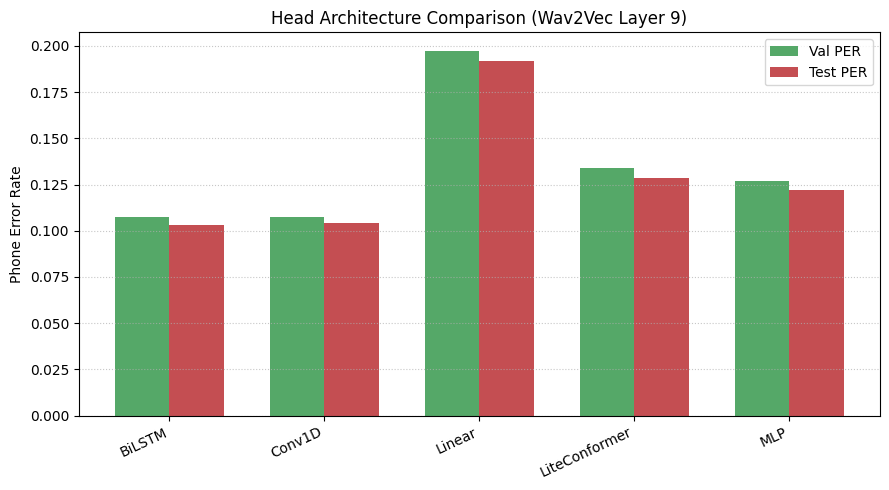

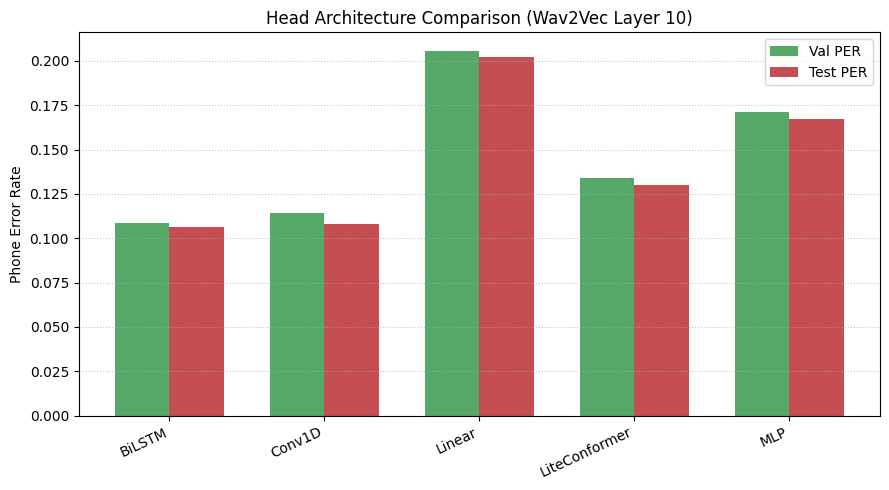

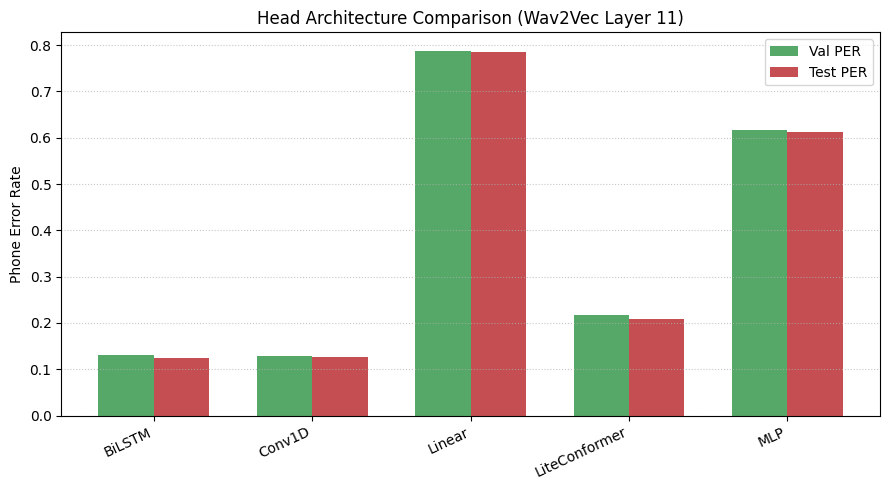

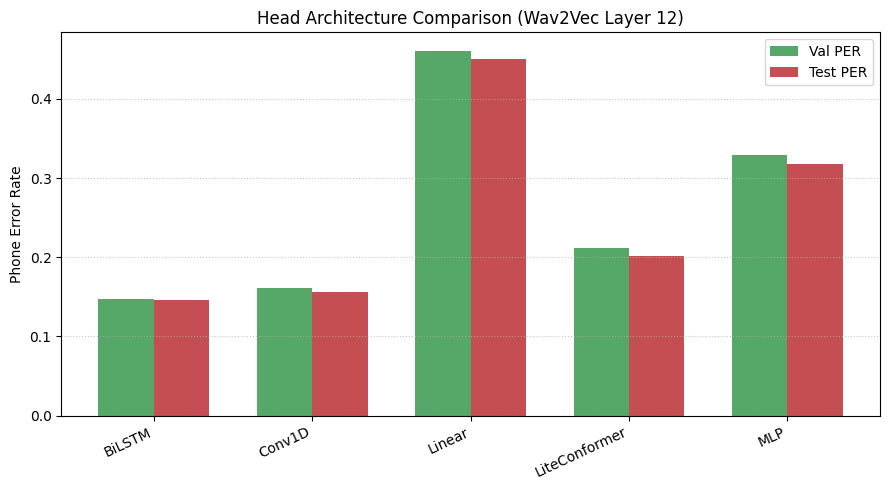

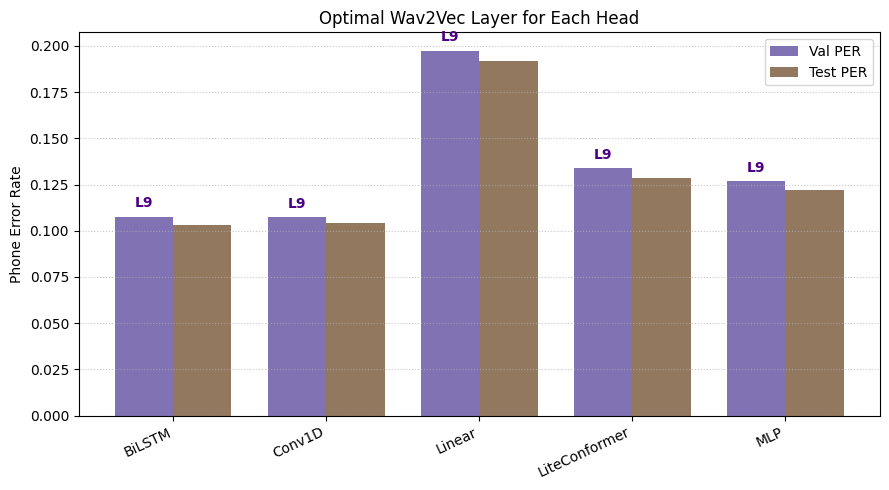

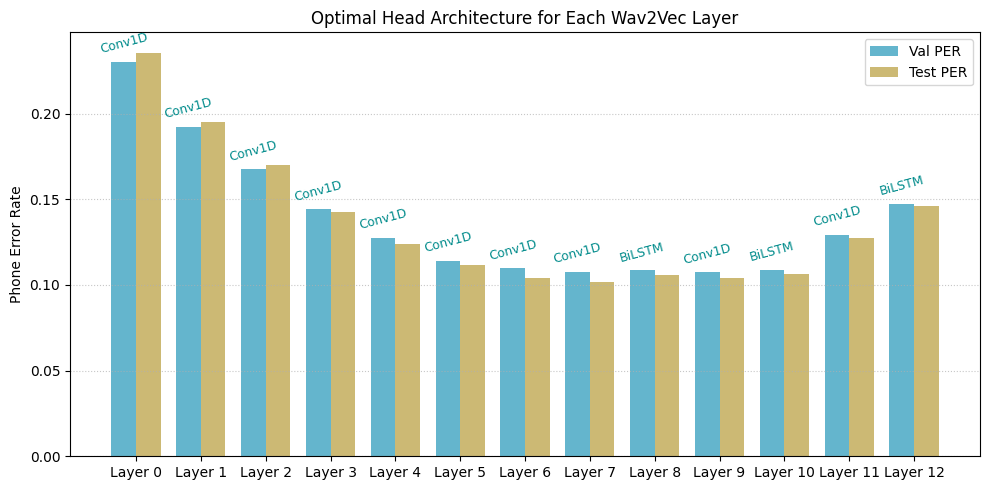

In [27]:
my_data_file = "./results/wav2vec2/benchmark_history.json"

processed_df = load_and_process_logs(my_data_file)

chart_layer_metrics(processed_df, base_model_name="Wav2Vec", target_head="Linear")
chart_layer_metrics(processed_df, base_model_name="Wav2Vec", target_head="MLP")
chart_layer_metrics(processed_df, base_model_name="Wav2Vec", target_head="BiLSTM")
chart_layer_metrics(processed_df, base_model_name="Wav2Vec", target_head="Conv1D")
chart_layer_metrics(processed_df, base_model_name="Wav2Vec", target_head="LiteConformer")
chart_head_metrics(processed_df, base_model_name="Wav2Vec", target_layer=0)
chart_head_metrics(processed_df, base_model_name="Wav2Vec", target_layer=1)
chart_head_metrics(processed_df, base_model_name="Wav2Vec", target_layer=2)
chart_head_metrics(processed_df, base_model_name="Wav2Vec", target_layer=3)
chart_head_metrics(processed_df, base_model_name="Wav2Vec", target_layer=4)
chart_head_metrics(processed_df, base_model_name="Wav2Vec", target_layer=5)
chart_head_metrics(processed_df, base_model_name="Wav2Vec", target_layer=6)
chart_head_metrics(processed_df, base_model_name="Wav2Vec", target_layer=7)
chart_head_metrics(processed_df, base_model_name="Wav2Vec", target_layer=8)
chart_head_metrics(processed_df, base_model_name="Wav2Vec", target_layer=9)
chart_head_metrics(processed_df, base_model_name="Wav2Vec", target_layer=10)
chart_head_metrics(processed_df, base_model_name="Wav2Vec", target_layer=11)
chart_head_metrics(processed_df, base_model_name="Wav2Vec", target_layer=12)
highlight_top_layer_per_head(processed_df, base_model_name="Wav2Vec")
highlight_top_head_per_layer(processed_df, base_model_name="Wav2Vec")